#Adidas vs Nike sales comparison

ENTC A1


Group 1:

Akshat Deshmukh - 25070123008

Yugansh Nirwan - 25070123004

Aadi Havele - 25070123001

Ansh Srivastava - 25070123011


In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Adidas Vs Nike.csv")

df.head()
df.info()
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3268 entries, 0 to 3267
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product Name   3268 non-null   object 
 1   Product ID     3268 non-null   object 
 2   Listing Price  3268 non-null   int64  
 3   Sale Price     3268 non-null   int64  
 4   Discount       3268 non-null   int64  
 5   Brand          3268 non-null   object 
 6   Description    3265 non-null   object 
 7   Rating         3268 non-null   float64
 8   Reviews        3268 non-null   int64  
 9   Last Visited   3268 non-null   object 
dtypes: float64(1), int64(4), object(5)
memory usage: 255.4+ KB


,Product Name,Product ID,Listing Price,Sale Price,Discount,Brand,Description,Rating,Reviews,Last Visited
0,Women's adidas Originals NMD_Racer Primeknit S...,AH2430,14999,7499,50,Adidas Adidas ORIGINALS,Channeling the streamlined look of an '80s rac...,4.8,41,2020-04-13T15:06:14
1,Women's adidas Originals Sleek Shoes,G27341,7599,3799,50,Adidas ORIGINALS,"A modern take on adidas sport heritage, tailor...",3.3,24,2020-04-13T15:06:15
2,Women's adidas Swim Puka Slippers,CM0081,999,599,40,Adidas CORE / NEO,These adidas Puka slippers for women's come wi...,2.6,37,2020-04-13T15:06:15
3,Women's adidas Sport Inspired Questar Ride Shoes,B44832,6999,3499,50,Adidas CORE / NEO,"Inspired by modern tech runners, these women's...",4.1,35,2020-04-13T15:06:15
4,Women's adidas Originals Taekwondo Shoes,D98205,7999,3999,50,Adidas ORIGINALS,This design is inspired by vintage Taekwondo s...,3.5,72,2020-04-13T15:06:15
...,...,...,...,...,...,...,...,...,...,...
3263,Air Jordan 8 Retro,CI1236-100,15995,12797,0,Nike,The Air Jordan 8 Retro recaptures the memorabl...,5.0,1,2020-04-13T15:41:01
3264,Nike Phantom Venom Club IC,AO0578-717,4995,3497,0,Nike,The Nike Phantom Venom Club IC is engineered f...,0.0,0,2020-04-13T15:41:03
3265,Nike Mercurial Superfly 7 Academy TF,AT7978-414,8495,5947,0,Nike,The soft upper of the Nike Mercurial Superfly ...,5.0,1,2020-04-13T15:41:07
3266,Nike Air Max 98,AH6799-300,0,16995,0,Nike,The Nike Air Max 98 features the OG design lin...,4.0,4,2020-04-13T15:41:19


#Data Cleaning and Preprocessing:

In [15]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [16]:
df.isnull().sum()

# Fill numeric columns
df['listing_price'] = df['listing_price'].fillna(df['listing_price'].mean())
df['sale_price'] = df['sale_price'].fillna(df['sale_price'].mean())
df['rating'] = df['rating'].fillna(df['rating'].mean())
df['reviews'] = df['reviews'].fillna(0)

In [18]:
# Converting Datatype:
df['last_visited'] = pd.to_datetime(df['last_visited'])
df.head()

,product_name,product_id,listing_price,sale_price,discount,brand,description,rating,reviews,last_visited
0,Women's adidas Originals NMD_Racer Primeknit S...,AH2430,14999,7499,50,Adidas Adidas ORIGINALS,Channeling the streamlined look of an '80s rac...,4.8,41,2020-04-13 15:06:14
1,Women's adidas Originals Sleek Shoes,G27341,7599,3799,50,Adidas ORIGINALS,"A modern take on adidas sport heritage, tailor...",3.3,24,2020-04-13 15:06:15
2,Women's adidas Swim Puka Slippers,CM0081,999,599,40,Adidas CORE / NEO,These adidas Puka slippers for women's come wi...,2.6,37,2020-04-13 15:06:15
3,Women's adidas Sport Inspired Questar Ride Shoes,B44832,6999,3499,50,Adidas CORE / NEO,"Inspired by modern tech runners, these women's...",4.1,35,2020-04-13 15:06:15
4,Women's adidas Originals Taekwondo Shoes,D98205,7999,3999,50,Adidas ORIGINALS,This design is inspired by vintage Taekwondo s...,3.5,72,2020-04-13 15:06:15


In [19]:
df = df.drop_duplicates()

In [21]:
#Creating new 'Discount Percent' column:
df['discount_percent'] = (df['listing_price'] - df['sale_price']) / df['listing_price'] * 100

df['month'] = df['last_visited'].dt.month

df['brand'] = df['brand'].str.lower()
df.head()

,product_name,product_id,listing_price,sale_price,discount,brand,description,rating,reviews,last_visited,discount_percent,month
0,Women's adidas Originals NMD_Racer Primeknit S...,AH2430,14999,7499,50,adidas adidas originals,Channeling the streamlined look of an '80s rac...,4.8,41,2020-04-13 15:06:14,50.003334,4
1,Women's adidas Originals Sleek Shoes,G27341,7599,3799,50,adidas originals,"A modern take on adidas sport heritage, tailor...",3.3,24,2020-04-13 15:06:15,50.006580,4
2,Women's adidas Swim Puka Slippers,CM0081,999,599,40,adidas core / neo,These adidas Puka slippers for women's come wi...,2.6,37,2020-04-13 15:06:15,40.040040,4
3,Women's adidas Sport Inspired Questar Ride Shoes,B44832,6999,3499,50,adidas core / neo,"Inspired by modern tech runners, these women's...",4.1,35,2020-04-13 15:06:15,50.007144,4
4,Women's adidas Originals Taekwondo Shoes,D98205,7999,3999,50,adidas originals,This design is inspired by vintage Taekwondo s...,3.5,72,2020-04-13 15:06:15,50.006251,4


In [58]:
#Creating new 'Price Category' column:
df['price_category'] = pd.cut(df['sale_price'],
                             bins=[0,5000,10000,20000],
                             labels=['Low','Medium','High'])
df.head()

,product_name,product_id,listing_price,sale_price,discount,brand,description,rating,reviews,last_visited,discount_percent,month,price_category
0,Women's adidas Originals NMD_Racer Primeknit S...,AH2430,14999,7499,50,adidas,Channeling the streamlined look of an '80s rac...,4.8,41,2020-04-13 15:06:14,50.003334,4,Medium
1,Women's adidas Originals Sleek Shoes,G27341,7599,3799,50,adidas,"A modern take on adidas sport heritage, tailor...",3.3,24,2020-04-13 15:06:15,50.006580,4,Low
2,Women's adidas Swim Puka Slippers,CM0081,999,599,40,adidas,These adidas Puka slippers for women's come wi...,2.6,37,2020-04-13 15:06:15,40.040040,4,Low
3,Women's adidas Sport Inspired Questar Ride Shoes,B44832,6999,3499,50,adidas,"Inspired by modern tech runners, these women's...",4.1,35,2020-04-13 15:06:15,50.007144,4,Low
4,Women's adidas Originals Taekwondo Shoes,D98205,7999,3999,50,adidas,This design is inspired by vintage Taekwondo s...,3.5,72,2020-04-13 15:06:15,50.006251,4,Low


In [40]:

# Step 1: check original values
print("Before cleaning:", df['brand'].unique())

# Step 2: clean text (remove spaces + lowercase)
df['brand'] = df['brand'].str.strip().str.lower()

# Step 3: merge all adidas variations into one
df['brand'] = df['brand'].apply(
    lambda x: 'adidas' if 'adidas' in x else x
)

# Step 4: verify result
print("After cleaning:", df['brand'].unique())

Before cleaning: ['adidas adidas originals' 'adidas' 'adidas core / neo'
 'adidas sport performance' 'nike']
After cleaning: ['adidas' 'nike']


#Data Visualization:


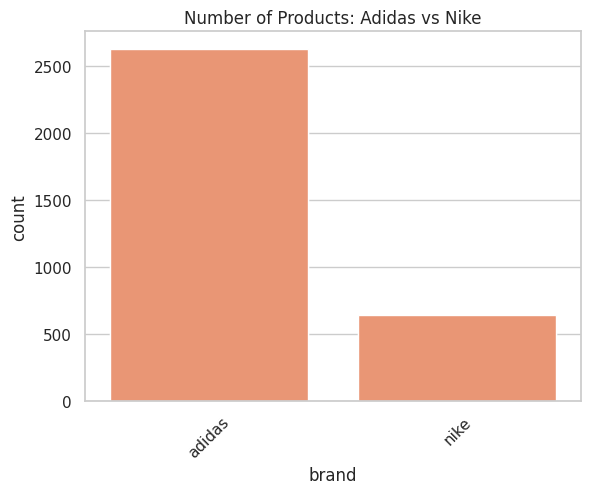

In [51]:
# Brand Count
sns.countplot(x='brand', data=df)
plt.title("Number of Products: Adidas vs Nike")
sns.countplot(x='brand', data=df)
plt.xticks(rotation=45)
plt.show()


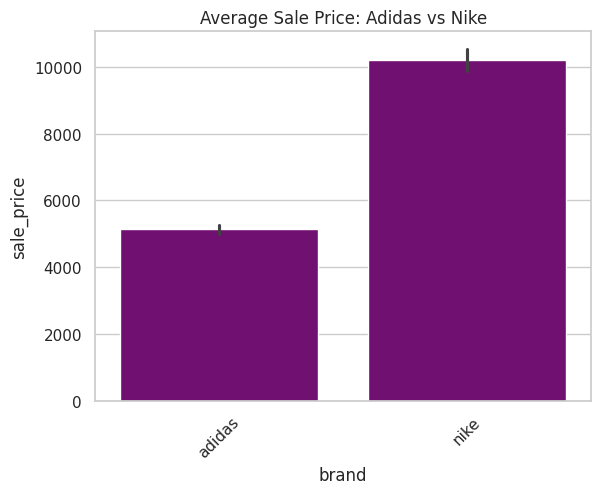

<Figure size 640x480 with 0 Axes>

In [54]:
#Average Sale price:
sns.barplot(x='brand', y='sale_price', data=df, color = 'purple')
plt.title("Average Sale Price: Adidas vs Nike")
plt.xticks(rotation=45)
plt.show()

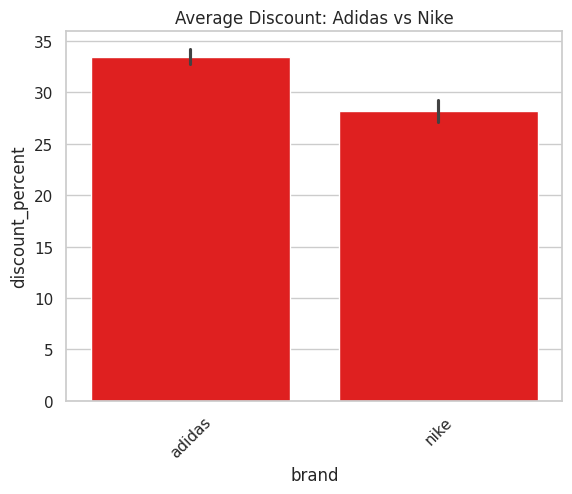

<Figure size 640x480 with 0 Axes>

In [53]:
#Average Discount:
sns.barplot(x='brand', y='discount_percent', data=df, color='red')
plt.title("Average Discount: Adidas vs Nike")
plt.xticks(rotation=45)
plt.show()

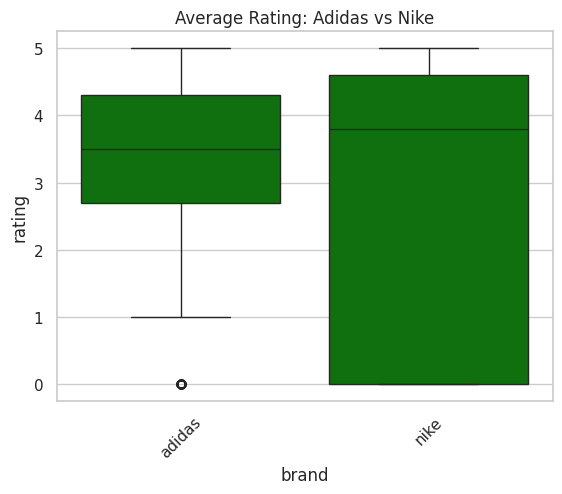

In [55]:
#Average Rating:
sns.boxplot(x='brand', y='rating', data=df, color='green')
plt.title("Average Rating: Adidas vs Nike")
plt.xticks(rotation=45)
plt.show()


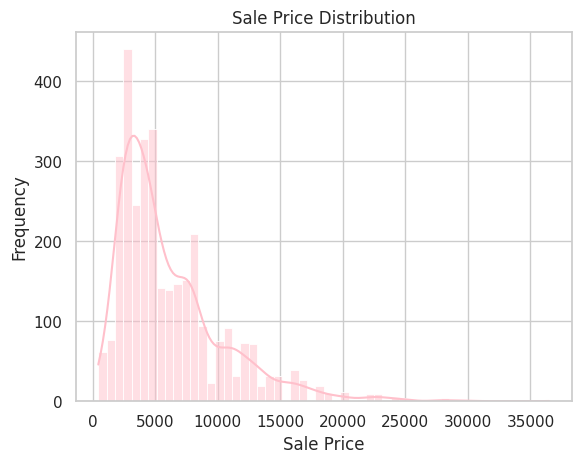

In [48]:
#Sale Price Distribution:
sns.histplot(df['sale_price'], kde=True, color='pink')
plt.title("Sale Price Distribution")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.show()

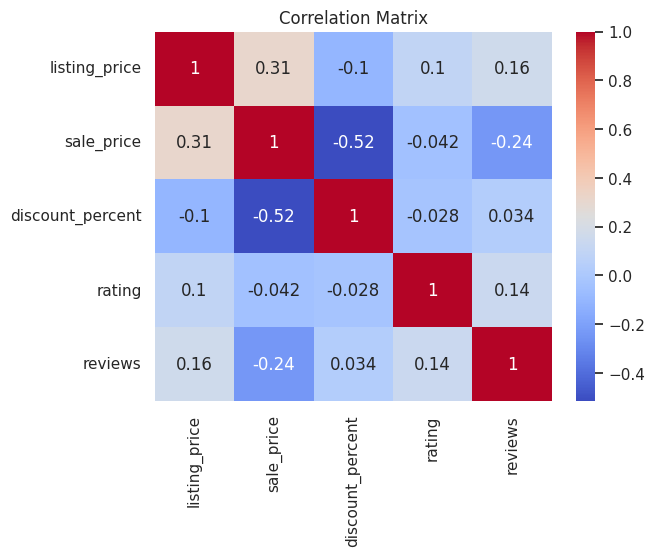

In [49]:
#Correlation Heatmap
corr = df[['listing_price','sale_price','discount_percent','rating','reviews']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

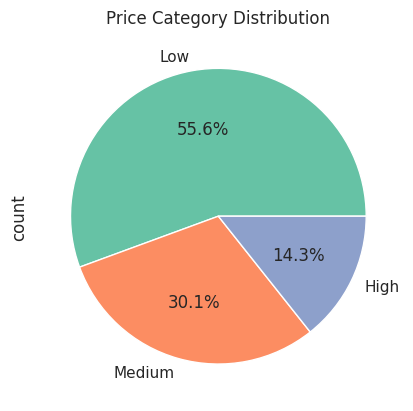

In [59]:
#Price Category distribution:
df['price_category'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Price Category Distribution")
plt.show()

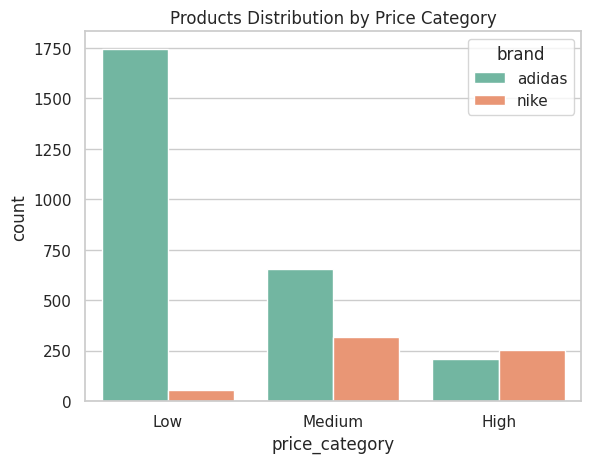

In [60]:
#Price distribution by Category:
sns.countplot(x='price_category', hue='brand', data=df)
plt.title("Products Distribution by Price Category")
plt.show()